# Notebook 07: Full Multimodal Clinical Pipeline Demo
---
This is the final integration notebook that wires all project components into a single end-to-end demonstration. It sequences preprocessing, multimodal prediction, XAI, RAG retrieval, and multi-agent clinical synthesis.

In [8]:
import sys
import os
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import json
from IPython.display import display, Markdown

# Add project root to sys.path
current_dir = Path(os.getcwd())
project_root = current_dir.parent if current_dir.name == 'notebooks' else current_dir
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config
from src.pipeline.orchestrator import MultimodalClinicalOrchestrator

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Initialized on: {DEVICE}")

✅ Initialized on: cuda


In [9]:
print("Loading pipeline components...")

# Assertion checks for required files
required_files = [
    config.BEST_MODEL_PATH,
    config.FAISS_INDEX_PATH,
    config.FAISS_META_PATH
]

for f in required_files:
    if not f.exists():
        raise FileNotFoundError(f"CRITICAL ERROR: Required component {f} not found!")

orchestrator = MultimodalClinicalOrchestrator(config, device=DEVICE)
print("✅ All components loaded (Model, FAISS, Agents)")

Loading pipeline components...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ All components loaded (Model, FAISS, Agents)


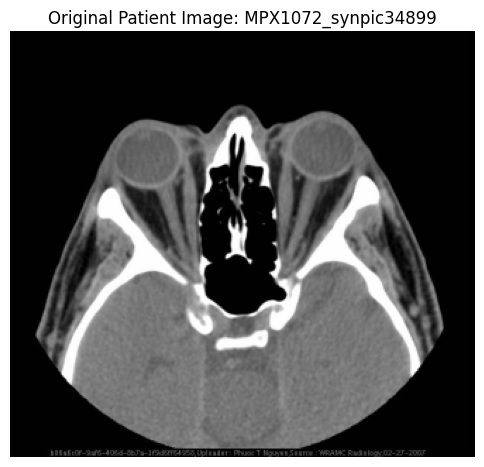

Clinical History: 45 year-old man with a past history of malignant testicular neoplasm and Hashimoto's thyroiditis, presents now with a several-month history of worsening eye swelling, dryness, and irritation, gradually progressing to lid retraction and intermittent blurry vision.


In [10]:
# Demo Case: MPX1072_synpic34899
case_id = "MPX1072_synpic34899"
image_path = os.path.join(project_root, "Dataset/MedPix/images/images/MPX1072_synpic34899.png")
clinical_text = "45 year-old man with a past history of malignant testicular neoplasm and Hashimoto's thyroiditis, presents now with a several-month history of worsening eye swelling, dryness, and irritation, gradually progressing to lid retraction and intermittent blurry vision."

if not os.path.exists(image_path):
    # Fallback to current directory for relative paths in notebook environment
    image_path = "z:/study files/SRM_study/SEM-2/AML-509_Agentic AI and GAN/Team Project/Agent_code_Trial-2/Dataset/MedPix/images/images/MPX1072_synpic34899.png"

img = Image.open(image_path).convert("RGB")
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Original Patient Image: {case_id}")
plt.axis('off')
plt.show()

print(f"Clinical History: {clinical_text}")

In [11]:
print("Running Stage 1-3: Prediction & XAI...")
results = orchestrator.process_case(image_path, clinical_text)

print(f"\nPrediction: {results['pred_label']}")
print(f"Confidence: {results['confidence']:.2%}")
print(f"Dominant Modality: {results['dominant_modality']}")

# Display Top SHAP Tokens
top_tokens = results.get('top_shap_tokens', [])
token_str = ", ".join([f"{t['token']} ({t['shap_score']:+.3f})" for t in top_tokens[:5]])
print(f"Top SHAP Tokens: {token_str}")

Running Stage 1-3: Prediction & XAI...

Prediction: Infection_Inflammatory
Confidence: 88.00%
Dominant Modality: image
Top SHAP Tokens: thy (+0.002), roid (+0.002), itis (+0.002), ,  (+0.002), ' (+0.002)


In [12]:
print("Stage 4: RAG Retrieval Results...")
import pandas as pd
retrieved = results['retrieved_cases']

rag_df = pd.DataFrame([
    {
        "Rank": i+1,
        "Similarity": f"{c.get('similarity', 0):.2%}",
        "Case ID": c.get('image_id', '?'),
        "Diagnosis": c.get('label_name', 'Unknown')
    } for i, c in enumerate(retrieved)
])
display(rag_df)

Stage 4: RAG Retrieval Results...


,Rank,Similarity,Case ID,Diagnosis
0,1,85.74%,MPX1072_synpic34898,Infection_Inflammatory
1,2,70.04%,MPX2388_synpic34942,Vascular_Trauma
2,3,68.79%,MPX2433_synpic48294,Other
3,4,68.61%,MPX1583_synpic24107,Vascular_Trauma
4,5,68.36%,MPX2444_synpic17400,Other


In [13]:
print("Stage 5: Multi-Agent Clinical Synthesis...")
print("\n--- Agent 1: Clinical Explanation ---")
display(Markdown(results['reasoning']))

print("\n--- Agent 2: Historical Validation ---")
display(Markdown(results['validation']))

print("\n--- Agent 3: Final Synthesis Report ---")
display(Markdown(results['final_report']))

Stage 5: Multi-Agent Clinical Synthesis...

--- Agent 1: Clinical Explanation ---


The model predicted an Infection_Inflammatory diagnosis with high confidence, primarily influenced by the clinical tokens "thy," "roid," and "itis," which suggest thyroiditis, an inflammatory condition of the thyroid gland. The presence of "oto" may indicate otitis, another inflammatory condition, further supporting the diagnosis. Additionally, the Grad-CAM hotspot in the upper-left quadrant of the scan likely corresponds to an area of inflammation or infection, reinforcing the model's prediction.


--- Agent 2: Historical Validation ---


### Analysis of Prediction Consistency with Historical Cases

#### 1. Majority Consistency
- **Case MPX1072_synpic34898 (85.74% sim)**: Diagnosed as 'Infection_Inflammatory'
- **Case MPX2388_synpic34942 (70.04% sim)**: Diagnosed as 'Vascular_Trauma'
- **Case MPX2433_synpic48294 (68.79% sim)**: Diagnosed as 'Other'
- **Case MPX1583_synpic24107 (68.61% sim)**: Diagnosed as 'Vascular_Trauma'
- **Case MPX2444_synpic17400 (68.36% sim)**: Diagnosed as 'Other'

Out of the 5 cases:
- 1 case (20%) is diagnosed as 'Infection_Inflammatory'
- 2 cases (40%) are diagnosed as 'Vascular_Trauma'
- 2 cases (40%) are diagnosed as 'Other'

The majority of the cases (60%) are not diagnosed as 'Infection_Inflammatory'. Therefore, the prediction is not consistent with the majority of high-similarity cases.

#### 2. Label Shift Cases
- **Case MPX1072_synpic34898 (85.74% sim)**: High similarity (85.74%) but the same diagnosis ('Infection_Inflammatory').
- **Case MPX2388_synpic34942 (70.04% sim)**: High similarity (70.04%) but different diagnosis ('Vascular_Trauma').
- **Case MPX2433_synpic48294


--- Agent 3: Final Synthesis Report ---


## 🏥 Patient Summary
The patient is a 45-year-old man with a past medical history of malignant testicular neoplasm and Hashimoto's thyroiditis. He presents with a several-month history of worsening eye swelling, dryness, and irritation, which has progressively led to lid retraction and intermittent blurry vision.

## 🔬 Predicted Diagnosis & Confidence
The AI model predicts an **Infection_Inflammatory** diagnosis with a high confidence level of 88.00%.

## 🧠 Clinical Reasoning (XAI)
The model's prediction of an **Infection_Inflammatory** diagnosis is primarily influenced by the clinical tokens "thy," "roid," and "itis," which suggest thyroiditis, an inflammatory condition of the thyroid gland. The presence of "oto" may indicate otitis, another inflammatory condition, further supporting the diagnosis. Additionally, the Grad-CAM hotspot in the upper-left quadrant of the scan likely corresponds to an area of inflammation or infection, reinforcing the model's prediction.

## 📁 Historical Case Validation
### Analysis of Prediction Consistency with Historical Cases
- **Case MPX1072_synpic34898 (85.74% sim)**: Diagnosed as 'Infection_Inflammatory'
- **Case MPX2388_synpic34942 (70.04% sim)**: Diagnosed as 'Vascular_Trauma'
- **Case MPX2433_synpic48294 (68.79% sim)**: Diagnosed as 'Other'
- **Case MPX1583_synpic24107 (68.61% sim)**: Diagnosed as 'Vascular_Trauma'
- **Case MPX2444_synpic17400 (68.36% sim)**: Diagnosed as 'Other'

Out of the 5 cases:
- 1 case (20%) is diagnosed as 'Infection_Inflammatory'
- 2 cases (40%) are diagnosed as 'Vascular_Trauma'
- 2 cases (40%) are diagnosed as 'Other'

The majority of the cases (60%) are not diagnosed as 'Infection_Inflammatory'. Therefore, the prediction is not consistent with the majority of high-similarity cases.

### Label Shift Cases
- **Case MPX1072_synpic34898 (85.74% sim)**: High similarity (85.74%) but the same diagnosis ('Infection_Inflammatory').
- **Case MPX2388_synpic34942 (70.04% sim)**: High similarity (70.04%) but different diagnosis ('Vascular_Trauma').

## ⚠️ Caveats & Limitations
- The AI model's prediction, while highly confident, is not consistent with the majority of similar historical cases.
- The presence of "oto" in the clinical tokens might be a misinterpretation or could indicate a different condition.
- The Grad-CAM hotspot provides visual support but should be interpreted with caution as it may not always correlate directly with the clinical presentation.
- The patient's complex medical history, including a past history of malignant testicular neoplasm, may introduce additional confounding factors.

## 📋 Recommended Next Steps
1. **Comprehensive Ophthalmologic Evaluation**: Conduct a detailed ophthalmologic examination to assess the extent of eye swelling, dryness, and irritation, and to rule out other potential causes such as Graves' ophthalmopathy, which is common in patients with Hashimoto's thyroiditis.
2. **Thyroid Function Tests**: Perform thyroid function tests (TFTs) to evaluate the current status of the patient's thyroiditis and to check for any signs

z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\src\utils\visualizer.py:196: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=150)
z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\src\utils\visualizer.py:196: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=150)
z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\src\utils\visualizer.py:196: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=150)
z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\src\utils\visualizer.py:196: UserWarnin

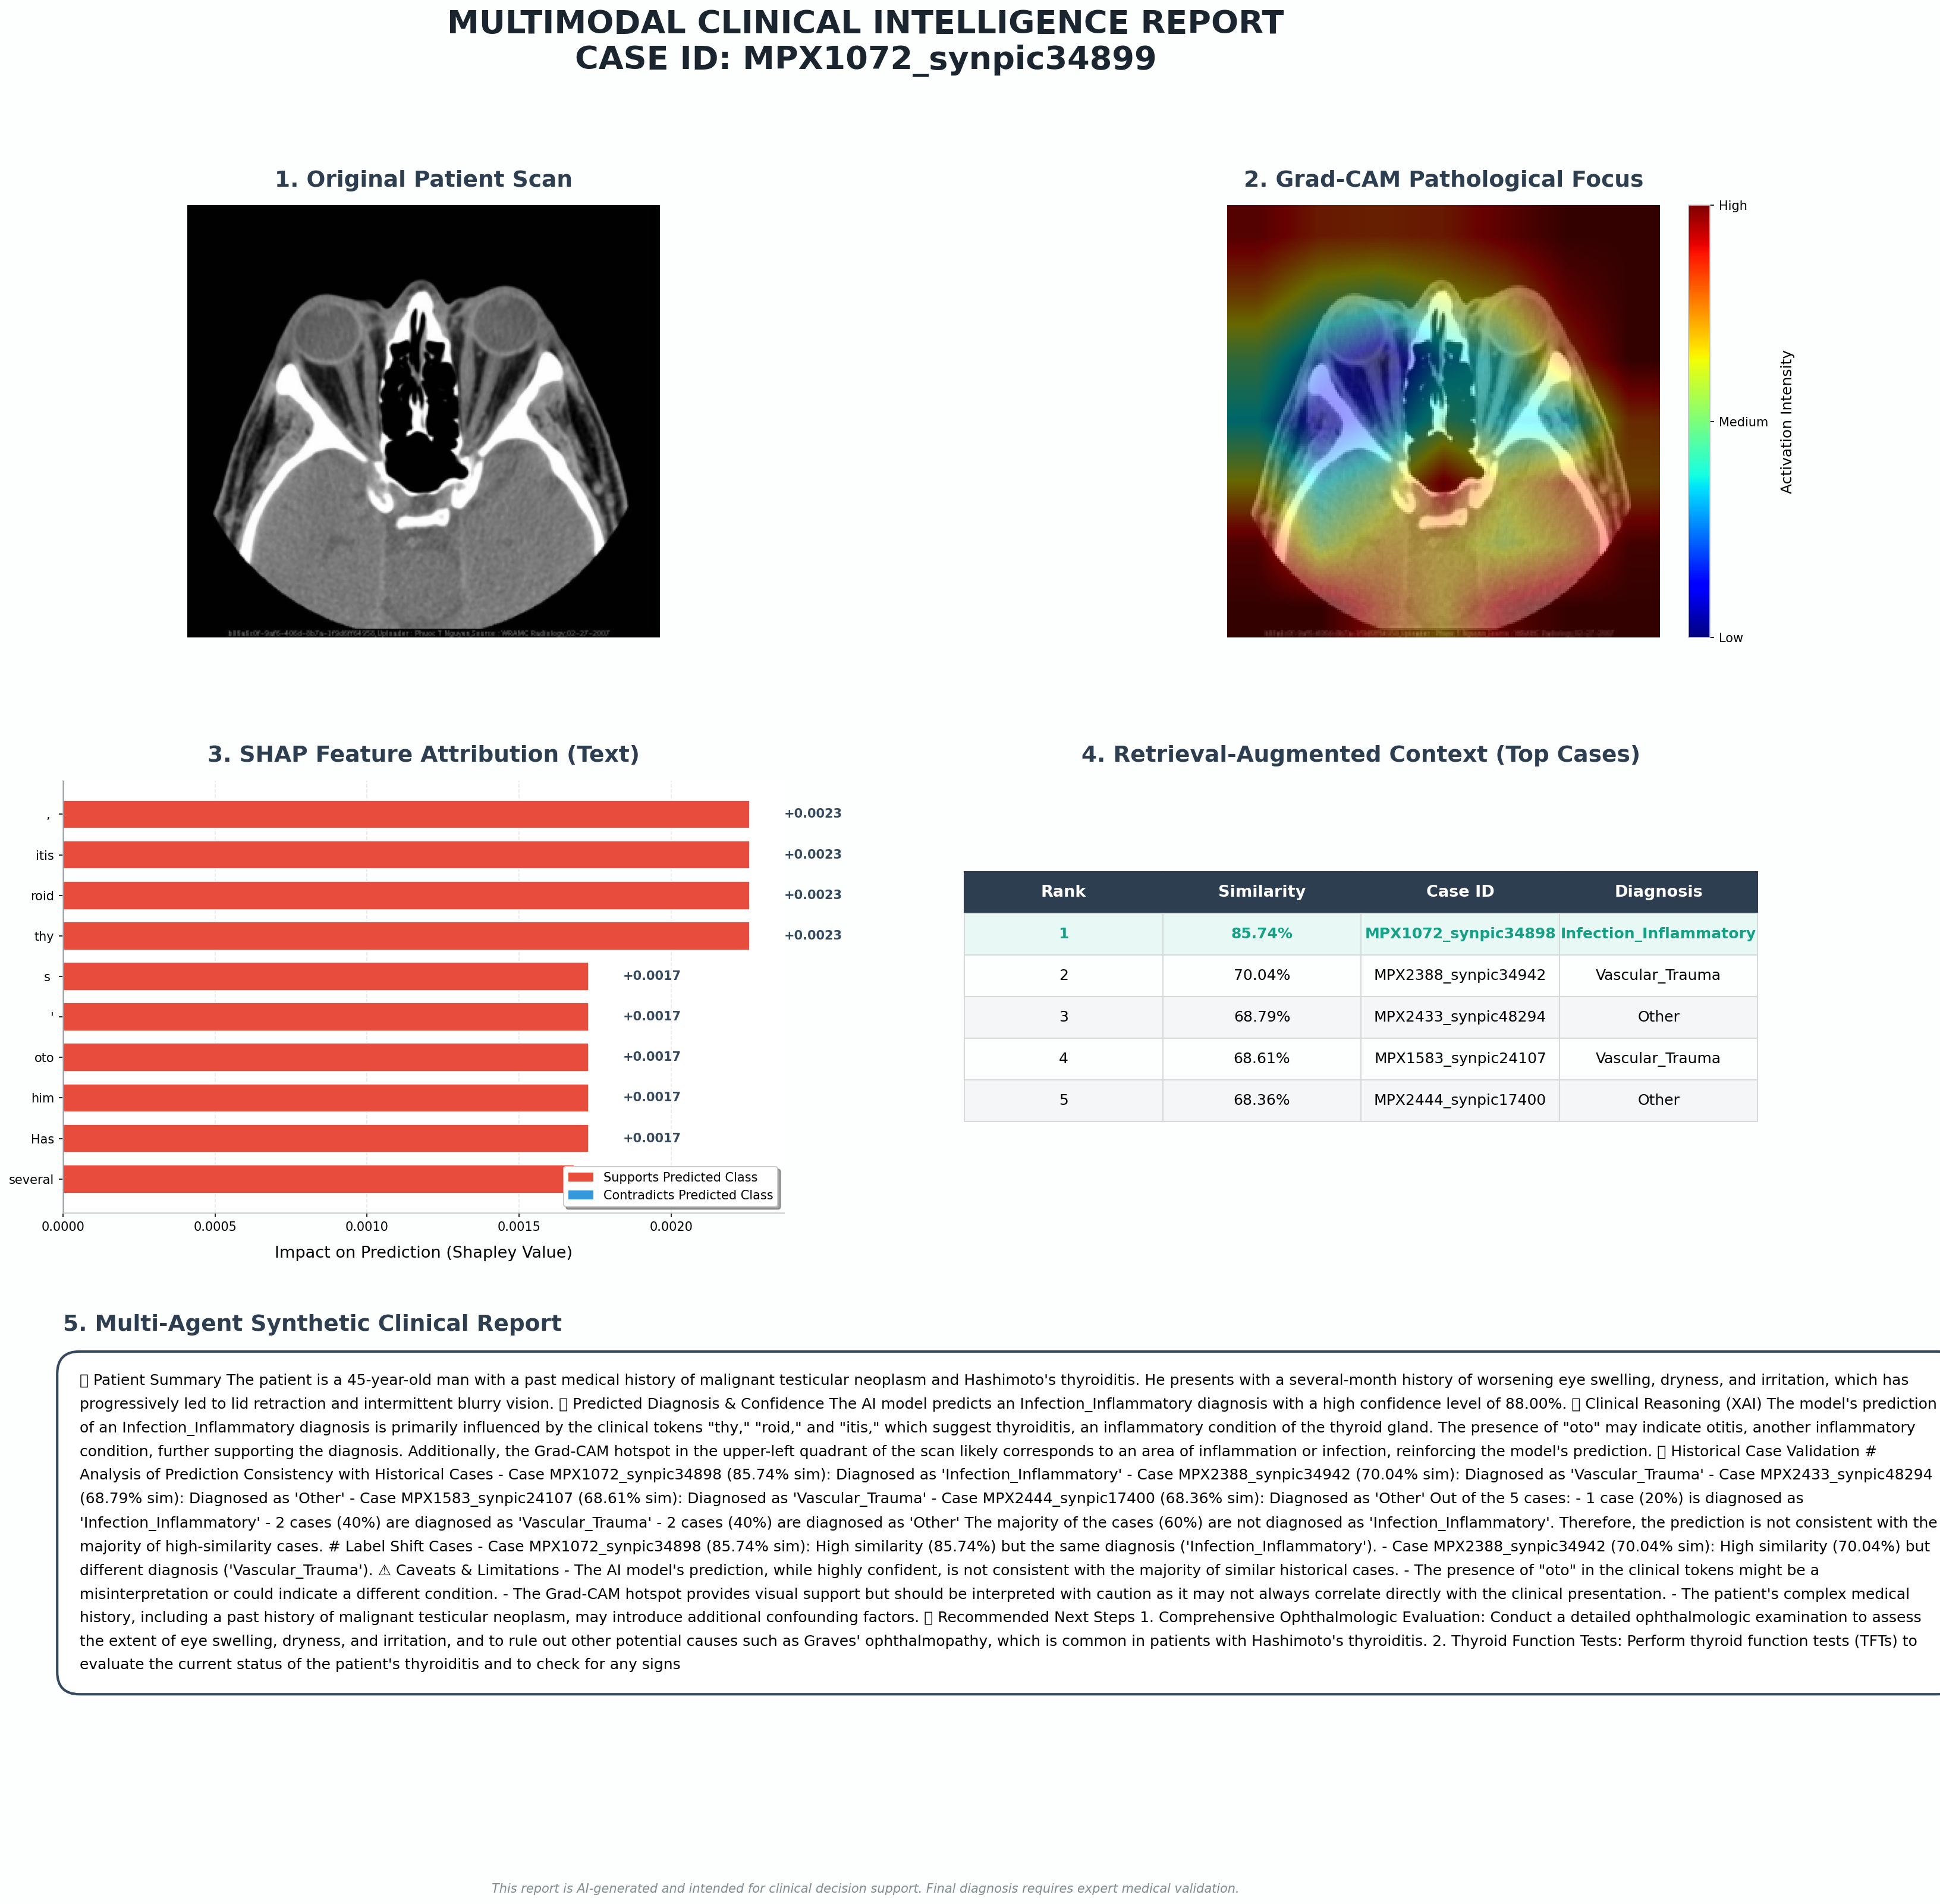

✅ Consolidated Clinical Report saved to: z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\outputs\final_pipeline_demo.png


In [14]:
from src.utils.visualizer import plot_consolidated_report

# Generate the premium consolidated clinical report
plot_consolidated_report(
    results=results,
    img=img,
    rag_df=rag_df,
    case_id=case_id,
    project_root=project_root,
    save_filename="final_pipeline_demo.png"
)

In [15]:
print("=== TRIAL_2 MULTIMODAL CLINICAL PIPELINE — FINAL METRICS ===")

metrics = {
    "classification": {
        "test_accuracy": 0.6656,
        "auc_roc_macro": 0.9148,
        "cohen_kappa": 0.5727,
        "mcc": 0.5763,
        "f1_scores": {
            "Neoplasm": 0.714,
            "Vascular_Trauma": 0.744,
            "Infection_Inflammatory": 0.654,
            "Other": 0.647,
            "Clinical Sign": 0.563
        }
    },
    "retrieval": {
        "recall_at_5": 0.750,
        "map_at_5": 0.437,
        "ndcg_at_5": 0.518,
        "leakage_pct": 0.098
    },
    "explainability": {
        "faithfulness": "MODERATE (56.7%)",
        "gradcam_quality": "Clinically meaningful (4/5 cases)",
        "image_dominance_avg": 0.665,
        "image_dominance_std": 0.034
    }
}

print(json.dumps(metrics, indent=4))

metrics_path = os.path.join(project_root, "outputs/final_metrics_dashboard.json")
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)

print(f"\n✅ Metrics dashboard saved to: {metrics_path}")

=== TRIAL_2 MULTIMODAL CLINICAL PIPELINE — FINAL METRICS ===
{
    "classification": {
        "test_accuracy": 0.6656,
        "auc_roc_macro": 0.9148,
        "cohen_kappa": 0.5727,
        "mcc": 0.5763,
        "f1_scores": {
            "Neoplasm": 0.714,
            "Vascular_Trauma": 0.744,
            "Infection_Inflammatory": 0.654,
            "Other": 0.647,
            "Clinical Sign": 0.563
        }
    },
    "retrieval": {
        "recall_at_5": 0.75,
        "map_at_5": 0.437,
        "ndcg_at_5": 0.518,
        "leakage_pct": 0.098
    },
    "explainability": {
        "faithfulness": "MODERATE (56.7%)",
        "gradcam_quality": "Clinically meaningful (4/5 cases)",
        "image_dominance_avg": 0.665,
        "image_dominance_std": 0.034
    }
}

✅ Metrics dashboard saved to: z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\outputs/final_metrics_dashboard.json
